In [1]:
import seaborn as sns
import pandas as pd
import json

In [2]:
df = pd.read_json("features/all_images.json")
# select only base images aka "normal", within the paper as "org"
df["is_base_img"] = df["image"].apply(lambda x: "normal_" in x)
df = df[df["is_base_img"]]
df

,image,niqe,color_fulness,tone,blur,saturation,fft,si,contrast,noise,dominant_color,cpbd,blur_stength,is_base_img
594,../../data/output_comb/normal_01_IMG_9832.png,18.177156,166.425681,0.769922,25253.887380,8.216077,45851.080823,0.306437,90.764517,0.955296,"[134, 136, 141]",0.928571,0.283196,True
595,../../data/output_comb/normal_02_IMG_0047.png,20.492998,157.968326,0.693202,8844.280107,10.337639,42229.135897,0.174992,84.480263,0.444543,"[182, 181, 185]",0.924138,0.404230,True
596,../../data/output_comb/normal_blume.png,20.609255,149.708612,0.300155,2312.830698,61.452213,40248.958256,0.091853,55.406995,0.769971,"[13, 14, 7]",0.350427,0.510702,True
597,../../data/output_comb/normal_IMG_1665.png,21.840824,21.101509,0.217018,3761.536613,45.101648,40006.186735,0.104331,77.543142,0.002218,"[32, 29, 43]",0.856557,0.355556,True
598,../../data/output_comb/normal_IMG_3867_4.png,19.424545,156.141938,0.000000,186638.763727,24.966117,53452.891801,0.448365,96.942463,2.122805,"[0, 1, 1]",0.873371,0.303635,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,../../data/output_comb/normal_p50.png,16.907326,162.910985,0.077509,44764.538538,11.423682,50825.293417,0.375960,84.013343,0.447036,"[252, 252, 253]",0.993333,0.227002,True
689,../../data/output_comb/normal_p51.png,19.676874,138.345259,0.273674,4886.768535,25.067554,40414.292048,0.131022,81.672406,1.035247,"[28, 25, 21]",0.970149,0.300344,True
690,../../data/output_comb/normal_p52.png,20.176188,59.530252,0.808581,8532.936836,41.405236,40870.164657,0.128065,93.346846,0.308875,"[245, 227, 208]",0.817568,0.395139,True
691,../../data/output_comb/normal_p53.png,20.402735,134.512450,0.621922,5803.153754,10.036271,40475.171406,0.146854,82.561314,0.308875,"[163, 162, 167]",0.897297,0.422985,True


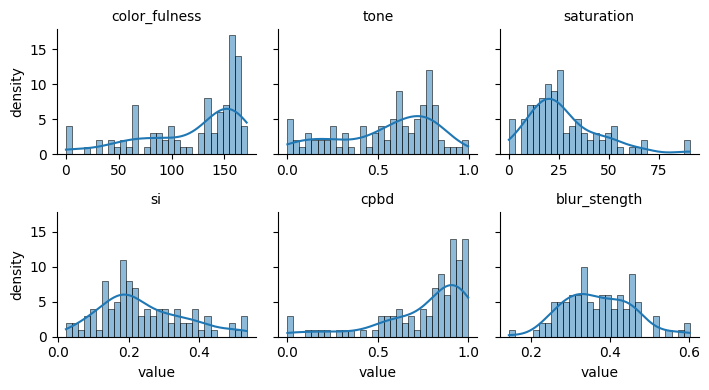

In [3]:
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
# First, let's select only the feature columns (excluding 'image' and any non-numeric)
# Based on your example, these are the feature columns:
feature_cols = ['niqe', 'color_fulness', 'tone', 'blur', 'saturation', 
                'fft', 'si', 'contrast', 'noise', 'cpbd', 'blur_stength']

# If you also want to include dominant_color, you might need to preprocess it
# since it appears to be a list. You could extract it as separate RGB features:
df['dominant_color_R'] = df['dominant_color'].apply(lambda x: x[0] if isinstance(x, list) else x)
df['dominant_color_G'] = df['dominant_color'].apply(lambda x: x[1] if isinstance(x, list) else x)
df['dominant_color_B'] = df['dominant_color'].apply(lambda x: x[2] if isinstance(x, list) else x)

# Add these to feature_cols if needed
feature_cols.extend(['dominant_color_R', 'dominant_color_G', 'dominant_color_B'])


feature_cols = ['color_fulness', 'tone', 'saturation', 'si', 'cpbd', 'blur_stength']

# Reshape data to long format
df_long = df.melt(value_vars=feature_cols, 
                  var_name='feature', 
                  value_name='value')

# Create FacetGrid
g = sns.FacetGrid(df_long, col='feature', col_wrap=3, 
                  sharex=False, sharey=True, height=2, aspect=1.2)
g.map(sns.histplot, 'value', kde=True, bins=30)
g.set_titles('{col_name}')
g.set_axis_labels('value', 'density')
g.tight_layout()

plt.savefig('feature_distributions.pdf', bbox_inches='tight')
plt.show()